In [1]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from collections import defaultdict
import pandas as pd

### Building R and X matrix for calculating Voltages later.

In [2]:
## Building the R and X matrices for the linearized voltage model
## These are also sensitivity matrices for how load changes at each bus affect voltage at each bus, relative to the root bus.

def build_tree_from_lines(line_df, root=114):

    children = defaultdict(list)
    parent = {}
    edge_rx = {}

    for _, row in line_df.iterrows():
        i = int(row["upstream bus"])
        j = int(row["downstream bus"])
        r = float(row["series resistance (pu)"])
        x = float(row["series reactance (pu)"])

        children[i].append(j)
        parent[j] = i
        edge_rx[(i, j)] = (r, x)

    buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"])))
    non_root = [b for b in buses if b != root]

    return children, parent, edge_rx, buses, non_root


# It returns the list of edges on the path from a given bus to the root bus, in order from root to bus.
def path_edges_to_root(bus, parent):
    edges = []
    cur = bus
    while cur in parent:
        par = parent[cur]
        edges.append((par, cur))
        cur = par
    edges.reverse()
    return edges


def build_RX_matrices(line_df, root=0):
    
    children, parent, edge_rx, buses, non_root = build_tree_from_lines(line_df, root=root)
    n = len(non_root)

    bus_to_idx = {b: k for k, b in enumerate(non_root)}
    path_map = {b: path_edges_to_root(b, parent) for b in non_root}

    R = np.zeros((n, n), dtype=float)
    X = np.zeros((n, n), dtype=float)

    for bi in non_root:
        for bj in non_root:
            common = set(path_map[bi]).intersection(set(path_map[bj]))  # Only the common edges contribute to the voltage drop difference between bi and bj
            r_sum = sum(edge_rx[e][0] for e in common)
            x_sum = sum(edge_rx[e][1] for e in common)

            i = bus_to_idx[bi]
            j = bus_to_idx[bj]
            R[i, j] = 2.0 * r_sum
            X[i, j] = 2.0 * x_sum

    return R, X, non_root, bus_to_idx

In [3]:
line_df = pd.read_csv("IEEE123 lines.csv")
R, X, non_root, bus_to_idx = build_RX_matrices(line_df, root=114)

### Building Bus loads

In [4]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]



In [5]:
buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"]))) # removing the root bus
buses.remove(114)
bldgs = df.index.get_level_values("bldg_id").unique()

np.random.seed(0)

bus_assignment = pd.DataFrame({
    "bldg_id": bldgs,
    "bus": np.random.choice(buses, size=len(bldgs))
})

In [6]:
df.reset_index(inplace=True)

df = df.merge(bus_assignment, on="bldg_id")

bus_load = (
    df
    .groupby(["timestamp","bus"])["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)

In [7]:
bus_load = bus_load.pivot(
    index="timestamp",
    columns="bus",
    values="out.electricity.net.energy_consumption"
)

bus_load = bus_load.fillna(0)

# Forcing all the buses to  exist even if they have no load
bus_load = bus_load.reindex(columns=buses, fill_value=0.0)

In [8]:
bus_load_kw = bus_load / 0.25 # Converting to KW : P = E/t



# --- Step 1: scale loads for voltage feasibility FIRST ---
peak_load_kw_raw = bus_load_kw.sum(axis=1).max()
S_base_temp = peak_load_kw_raw # temporary maximum power as base to calculate per-unit loads for voltage constraint evaluation.
bus_load_pu_temp = bus_load_kw / S_base_temp

pf = np.full(bus_load_pu_temp.shape[1], 0.9)
eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)
Z = R + X @ np.diag(eta_bus)

v_base = 1.0 - (bus_load_pu_temp.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("Raw peak load (kW):", peak_load_kw_raw)
print("Minimum baseline voltage before scaling:", vmin_actual)

# scaling all loads down so minimum voltage becomes 0.95 p.u.
scale_voltage = (1.0 - 0.95) / (1.0 - vmin_actual)
bus_load_kw_scaled = bus_load_kw * scale_voltage


# Step 2: setting transformer capacity AFTER voltage scaling 
peak_load_kw_scaled = bus_load_kw_scaled.sum(axis=1).max()
S_base = peak_load_kw_scaled
bus_load_pu = bus_load_kw_scaled / S_base  # Converting to per unit

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("\n")
print("Applied voltage scaling factor:", scale_voltage)
print("Peak load after voltage scaling (kW):", peak_load_kw_scaled)
print("Transformer rating S_base (kW):", S_base)
print("Peak load in pu after voltage scaling:", bus_load_pu.sum(axis=1).max())
print("Minimum baseline voltage after scaling:", vmin_actual)


# --- Step 3: further scale loads down to create headroom ---
bus_load_pu = 0.8 * bus_load_pu   # this is what we will use for the rest of analysis.
bus_load_kw_final = 0.8 * bus_load_kw_scaled # this is what we will use for the rest of analysis.

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_final = v_base.min()

print("\n")
print("Final peak load after headroom scaling (kW):", bus_load_kw_final.sum(axis=1).max())
print("Transformer rating remains fixed (kW):", S_base)
print("Final peak load in pu:", bus_load_pu.sum(axis=1).max())
print("Minimum voltage after headroom scaling:", vmin_final)
print("Available headroom at peak (pu):", 1.0 - bus_load_pu.sum(axis=1).max())
print("Available headroom at peak (kW):", S_base - bus_load_kw_final.sum(axis=1).max())



Raw peak load (kW): 464.5039999999999
Minimum baseline voltage before scaling: 0.9463326002665228


Applied voltage scaling factor: 0.9316642924440125
Peak load after voltage scaling (kW): 432.76179049741353
Transformer rating S_base (kW): 432.76179049741353
Peak load in pu after voltage scaling: 1.0
Minimum baseline voltage after scaling: 0.9463326002665228


Final peak load after headroom scaling (kW): 346.20943239793087
Transformer rating remains fixed (kW): 432.76179049741353
Final peak load in pu: 0.7999999999999998
Minimum voltage after headroom scaling: 0.9570660802132182
Available headroom at peak (pu): 0.20000000000000018
Available headroom at peak (kW): 86.55235809948266


### EV Charging Dataset (Norway)

In [9]:
ev_df = pd.read_csv('EV/dataset_3a_aggregated.csv', sep=';')
ev_df = ev_df[['date_from', 'Synthetic_7_2kW']]

ev_df['Synthetic_7_2kW'] = (
    ev_df['Synthetic_7_2kW']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

ev_df['date_from'] = pd.to_datetime(ev_df['date_from'], dayfirst=True)
ev_df = ev_df.set_index('date_from').sort_index()

ev_df.drop_duplicates(inplace=True)

# Resampling to 15-minutes interval
ev_df = ev_df.resample('15T').interpolate(method='linear')
ev_df =  ev_df.loc['2019-01-01 00:15:00':'2020-01-01 00:00:00']
ev_df.index = ev_df.index - pd.DateOffset(years=12)

C:\Users\gcsar\AppData\Local\Temp\ipykernel_1572\105924172.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ev_df = ev_df.resample('15T').interpolate(method='linear')


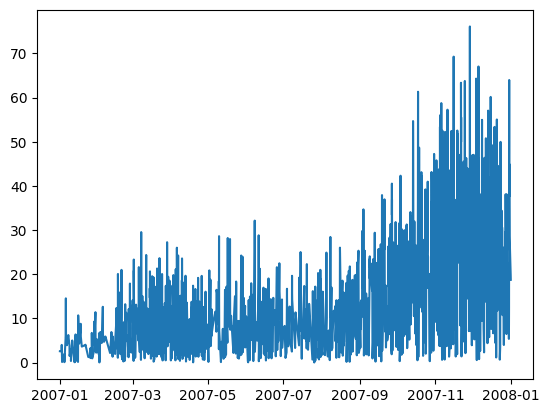

In [10]:
plt.plot(ev_df['Synthetic_7_2kW'])

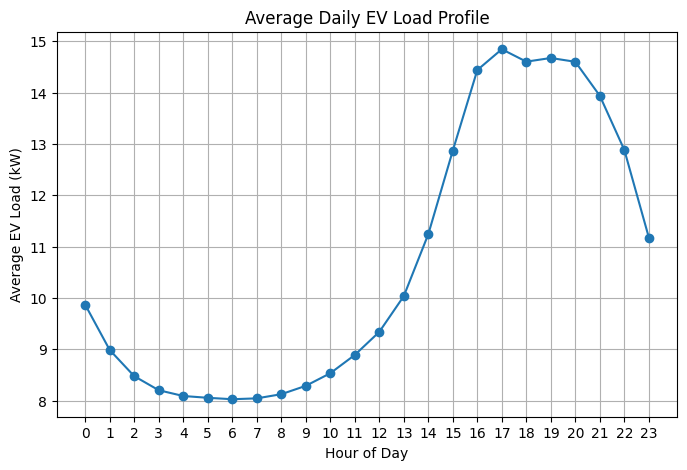

In [11]:
ev_df['hour'] = ev_df.index.hour

# Compute average load per hour
hourly_profile = ev_df.groupby('hour')['Synthetic_7_2kW'].mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(hourly_profile.index, hourly_profile.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average EV Load (kW)')
plt.title('Average Daily EV Load Profile')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

### Hosting Capacity

In [12]:
def dynamic_hosting_capacity_network(
    load_bus_t,          # shape (T, n), positive loads
    R, X,                # shape (n, n)
    lhat_new,            # shape (T,)
    host_idx,            # integer index of host bus in ordering
    p0_bar,              # transformer limit
    v0=1.0,
    vmin=0.95,
    pf=0.97,
):
    T, n = load_bus_t.shape

    vmin = np.full(n, float(vmin))
    pf = np.full(n, float(pf))
    eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)

    C_res = np.full(T, np.inf, dtype=float)
    C_dyn = np.full(T, np.inf, dtype=float)

    l_agg = load_bus_t.sum(axis=1)

    # Z = R + X diag(eta)
    Z = R + X @ np.diag(eta_bus)

    for t in range(T):
        ell = load_bus_t[t, :]

        # transformer headroom
        headroom_tx = p0_bar - l_agg[t]

        # voltage headroom
        numerator = v0 - vmin - (Z @ ell)
        denominator = Z[:, host_idx]

        valid = denominator > 1e-12
        if np.any(valid):
            headroom_v = np.min(numerator[valid] / denominator[valid])
        else:
            headroom_v = np.inf

        C_res[t] = min(headroom_tx, headroom_v)

        if lhat_new[t] > 1e-12:
            C_dyn[t] = C_res[t] / lhat_new[t]
        else:
            C_dyn[t] = np.inf

    return C_res, C_dyn

### CVAR With No Curtailment Budget

In [13]:
# Normalized flexible load profile (EV charing profile in this case)

ev_profile = ev_df["Synthetic_7_2kW"].copy()
ev_profile = ev_profile.reindex(bus_load_pu.index)

# normalize
lhat = ev_profile.to_numpy(dtype=float)
lhat = lhat / lhat.max()

print("Length of lhat:", len(lhat))
print("Min/Max of lhat:", lhat.min(), lhat.max())

# or comment out all above and use the following dummy lhat for testing
# lhat = np.ones(len(bus_load_pu)) # Normalized load

Length of lhat: 35040
Min/Max of lhat: 0.0001314233144959916 1.0


In [26]:
T = len(bus_load_pu)


# candidate interconnection bus
host_bus_number = 13

host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95

C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.9,
)


alpha = 0.95
epsilon = 0.0

# Decision variables
C = cp.Variable(nonneg=True, name="C")   # hosting capacity
eta = cp.Variable(name="eta")            # VaR-like auxiliary variable
s = cp.Variable(T, nonneg=True, name="s")# slack for tail losses


constraints = [
    s >= C * lhat - C_res - eta,
    eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,
    C <= 1.0,
]

# Maximize hosting capacity
obj = cp.Maximize(C)

problem = cp.Problem(obj, constraints)
problem.solve(solver="ECOS", verbose=True)

print("Optimal radial CVaR hosting capacity C:", C.value)
print("In KW :", C.value * S_base)
print("Optimal eta:", eta.value)

(CVXPY) Mar 20 07:35:35 PM: Your problem has 35042 variables, 35042 constraints, and 0 parameters.
(CVXPY) Mar 20 07:35:35 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 20 07:35:35 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 20 07:35:35 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 20 07:35:35 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 20 07:35:35 PM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 20 07:35:35 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 20 07:35:35 PM: Applying reduction FlipObjective
(CVXPY) Mar 20 07:35:35 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 20 07:35:35 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 20 07:35:35 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 20 07:35:35 PM: Apply

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Mar 20 07:35:36 PM: Problem status: optimal
(CVXPY) Mar 20 07:35:36 PM: Optimal value: 1.000e+00
(CVXPY) Mar 20 07:35:36 PM: Compilation took 1.631e-01 seconds
(CVXPY) Mar 20 07:35:36 PM: Solver (including time spent in interface) took 8.658e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Optimal radial CVaR hosting capacity C: 0.9999999999970637
In KW : 432.7617904961428
Optimal eta: -0.1557907359357072


## Remarks
The optimal hosting capacity is the same as the transformer limit. The key equation is total_load = l^agg + C*lhat.
So, the ev load might be small when base load is in peak, thus allowing more capacity. I added a constraint s.t 
the hosting capacity is capped at feeder limit. Otherwise the hosting capacity goes beyond feeder limit. Because, we are using cvar (weaker constraint than the GU et al paper), so maximizing C will increase the limit a bit until it violates the tail risk by epsilon.

In [15]:
t_peak_feeder = np.argmax(bus_load_pu.sum(axis=1).to_numpy())
print("Feeder peak baseline load (pu):", bus_load_pu.sum(axis=1).max())
print("lhat at feeder peak:", lhat[t_peak_feeder])
print("Added load at feeder peak (pu):", C.value * lhat[t_peak_feeder])
print("Total load at feeder peak (pu):",
      bus_load_pu.sum(axis=1).to_numpy()[t_peak_feeder] + C.value * lhat[t_peak_feeder])

Feeder peak baseline load (pu): 0.7999999999999998
lhat at feeder peak: 0.15606518596399
Added load at feeder peak (pu): 0.1640010176905794
Total load at feeder peak (pu): 0.9640010176905792


In [25]:
z = C.value * lhat - C_res
print("Max violation:", z.max())
print("Fraction violated:", np.mean(z > 1e-8))

Max violation: 0.5171725445576354
Fraction violated: 0.01937785388127854


### CVAR with Curtailment Budget

In [19]:
T = len(lhat)


alpha = 0.95
epsilon = 0.0

# Curtailment budget parameters
dt = 0.25      # 15-minute intervals = 0.25 hour
B_kwh = 50   # total curtailment energy budget in MWh
mu = 0.2       # max 20% curtailment per timestamp

# Decision variables
C = cp.Variable(nonneg=True, name="C")     # hosting capacity
eta = cp.Variable(name="eta")              # VaR-like auxiliary variable
s = cp.Variable(T, nonneg=True, name="s")  # CVaR slack variables
y = cp.Variable(T, nonneg=True, name="y")  # curtailed amount at each time

zeta = C * lhat - y - C_res
constraints = [
    # CVaR epigraph constraints
    s >= zeta - eta,
    eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,

    # Curtailment feasibility constraints
    y <= C * lhat,          # cannot curtail more than the requested added load
    y <= mu * C * lhat,     # per-slot curtailment cap
    cp.sum(y) * dt <= B_kwh # total curtailment energy budget
]

obj = cp.Maximize(C)
problem = cp.Problem(obj, constraints)

problem.solve(solver="ECOS", verbose=True)

print("Optimal radial CVaR hosting capacity C (pu):", C.value)
print("Optimal radial CVaR hosting capacity C (KW):", C.value * S_base)   
print("Optimal eta:", eta.value)
print("Total curtailed energy (kWh):", np.sum(y.value) * dt)
print("Max curtailment in any slot (pu):", np.max(y.value))
print("Number of slots with curtailment:", np.sum(y.value > 1e-8))

(CVXPY) Mar 20 05:31:31 PM: Your problem has 70082 variables, 105122 constraints, and 0 parameters.
(CVXPY) Mar 20 05:31:31 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 20 05:31:31 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 20 05:31:31 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 20 05:31:31 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 20 05:31:31 PM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 20 05:31:31 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 20 05:31:31 PM: Applying reduction FlipObjective
(CVXPY) Mar 20 05:31:31 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 20 05:31:31 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 20 05:31:31 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 20 05:31:31 PM: Appl

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Mar 20 05:31:34 PM: Problem status: optimal
(CVXPY) Mar 20 05:31:34 PM: Optimal value: 1.284e+00
(CVXPY) Mar 20 05:31:34 PM: Compilation took 1.327e-01 seconds
(CVXPY) Mar 20 05:31:34 PM: Solver (including time spent in interface) took 2.516e+00 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Optimal radial CVaR hosting capacity C (pu): 1.2842263349951033
Optimal radial CVaR hosting capacity C (KW): 555.764088136412
Optimal eta: -0.08149544632665909
Total curtailed energy (kWh): 49.99999999999616
Max curtailment in any slot (pu): 0.25684526699887406
Number of slots with curtailment: 2081


In [17]:
lambda_y = 1e4   # large penalty on curtailment

# baseline feeder load from your notebook
load_bus_t = bus_load_pu.to_numpy()   # shape (T, n)
T, n = load_bus_t.shape

# candidate interconnection bus
host_bus_number = 13
host_idx = bus_to_idx[host_bus_number]

# datacenter target capacity
C_target = 2.0 / S_base   
lhat = np.ones(T)

# Decision variables
P_gen = cp.Variable(nonneg=True, name="P_gen")      # generator rating (pu)
p_gen = cp.Variable(T, nonneg=True, name="p_gen")   # generator dispatch (pu)
y = cp.Variable(T, nonneg=True, name="y")           # curtailment (pu)

# unit vector for host bus
e_host = np.zeros(n)
e_host[host_idx] = 1.0

constraints = [
    p_gen <= P_gen,
    y <= C_target * lhat
]

# Uncomment this for strict zero curtailment
# constraints += [y == 0]

for t in range(T):
    # baseline feeder load at time t
    ell_t = load_bus_t[t, :]   # this replaces ell

    # net new load after generator and curtailment
    net_dc = C_target * lhat[t] - p_gen[t] - y[t]

    # real-power injection vector
    # baseline loads + datacenter load
    p_t = -ell_t - e_host * net_dc

    v_t = v0 * np.ones(n) + Z @ p_t

    

    constraints += [
        v_t >= vmin,
        -cp.sum(p_t) <= p0_bar
    ]

objective = cp.Minimize(
    P_gen + lambda_y * cp.sum(y) * dt
)

problem = cp.Problem(objective, constraints)
problem.solve(solver="ECOS", verbose=True)

print("Status:", problem.status)
print("Required generator size (pu):", P_gen.value)
print("Required generator size (kW):", P_gen.value * S_base)

if y.value is not None:
    print("Total curtailed energy (kWh):", np.sum(y.value) * dt * S_base)
    print("Max curtailment (pu):", np.max(y.value))
    print("Max curtailment (kW):", np.max(y.value) * S_base)

if p_gen.value is not None:
    print("Max generator dispatch (pu):", np.max(p_gen.value))
    print("Max generator dispatch (kW):", np.max(p_gen.value) * S_base)

                                     CVXPY                                     
                                     v1.7.5                                    


(CVXPY) Mar 17 11:35:29 AM: Your problem has 70081 variables, 4064640 constraints, and 0 parameters.
(CVXPY) Mar 17 11:35:42 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 17 11:35:42 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 17 11:35:42 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 17 11:35:42 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 17 11:36:01 AM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 17 11:36:01 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 17 11:36:01 AM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Mar 17 11:36:34 AM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 17 11:37:01 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 17 01:10:41 PM: Applying reduction ECOS
(CVXPY) Mar 17 01:10:49 PM: Finished problem compilation (took 5.707e+03 seconds).
(CVXPY) Mar 17 01:10:49 PM: Invoking solver ECOS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


c:\Users\gcsar\anaconda3\envs\RL\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
(CVXPY) Mar 17 01:11:25 PM: Problem status: optimal_inaccurate
(CVXPY) Mar 17 01:11:25 PM: Optimal value: 9.408e-10
(CVXPY) Mar 17 01:11:25 PM: Compilation took 5.707e+03 seconds
(CVXPY) Mar 17 01:11:25 PM: Solver (including time spent in interface) took 3.347e+01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal_inaccurate
Required generator size (pu): 9.408174000961631e-10
Required generator size (kW): 4.807147901756949e-07
Total curtailed energy (kWh): 0.0
Max curtailment (pu): 0.0
Max curtailment (kW): 0.0
Max generator dispatch (pu): 4.704095894438996e-10
Max generator dispatch (kW): 2.40357849528554e-07
